In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [5]:
df = pd.read_csv('customer_segmentation_data.csv')

In [6]:
# Check for null values in each column
print("Null values in each column:")
print(df.isnull().sum())

# Identify and display rows containing nulls
null_rows = df[df.isnull().any(axis=1)]
if not null_rows.empty:
    print("\nRows with null values:")
    print(null_rows)
else:
    print("\nNo null values found!")

Null values in each column:
id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

No null values found!


In [7]:
# Convert categorical text to numerical values
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})  # Gender encoding
df['preferred_category'] = df['preferred_category'].map({  # Category encoding
    'Electronics': 0,
    'Clothing': 1,
    'Groceries': 2,
    'Home & Garden': 3,
    'Sports': 4
})

In [8]:
# Normalize features using MinMax (0-1 range)
minmax_cols = ['age', 'spending_score', 'purchase_frequency']
df[minmax_cols] = MinMaxScaler().fit_transform(df[minmax_cols])

# Create robust income-to-spending ratio feature
df['income_spending_ratio'] = np.log1p(np.abs(df['income'])) / (np.log1p(np.abs(df['last_purchase_amount'])) + 1e-6)
df['income_spending_ratio'] = RobustScaler().fit_transform(df[['income_spending_ratio']])

# Standardize monetary features (mean=0, std=1)
std_cols = ['income', 'last_purchase_amount']
df[std_cols] = StandardScaler().fit_transform(df[std_cols])

# Convert membership years to loyalty tiers
df['loyalty_tier'] = pd.cut(df['membership_years'],
                           bins=[0, 2, 5, float('inf')],
                           labels=['0', '1', '2'])

# Remove unused columns
df.drop(columns=['membership_years', 'id'], inplace=True)

# Verify normalization results
print("Normalization Verification:")
print(df.describe().loc[['min', 'max', 'mean', 'std']].round(2))

Normalization Verification:
       age  gender  income  spending_score  purchase_frequency  \
min   0.00    0.00   -1.71            0.00                0.00   
max   1.00    2.00    1.80            1.00                1.00   
mean  0.51    0.97   -0.00            0.50                0.52   
std   0.29    0.83    1.00            0.29                0.29   

      preferred_category  last_purchase_amount  income_spending_ratio  
min                 0.00                 -1.63                  -0.85  
max                 4.00                  1.72                   7.57  
mean                2.03                 -0.00                   0.43  
std                 1.44                  1.00                   1.23  


In [9]:
# Step 6: Print first 20 rows of preprocessed data
print("\nPreprocessed Data (First 20 Rows):")
pd.set_option('display.max_columns', None)  # Show all columns
display(df.head(20))


Preprocessed Data (First 20 Rows):


,age,gender,income,spending_score,purchase_frequency,preferred_category,last_purchase_amount,income_spending_ratio,loyalty_tier
0,0.392157,1,0.316868,0.898990,0.469388,2,-1.281540,1.557713,1
1,0.058824,1,-0.282016,0.595960,0.836735,4,-1.523763,3.040871,0
2,0.823529,1,1.112778,0.292929,0.551020,1,-0.230005,0.297377,0
3,0.431373,2,-1.210096,0.737374,0.081633,3,1.690080,-0.692278,2
4,0.921569,1,1.523374,0.202020,0.489796,0,-0.491443,0.516418,1
5,0.254902,2,-0.911794,0.232323,0.591837,3,-1.371799,1.611879,1
6,0.019608,2,-0.999069,0.676768,0.857143,1,-1.017024,0.637773,1
7,0.490196,0,0.573286,0.939394,0.530612,2,0.819399,-0.182116,2
8,0.686275,0,-1.580562,0.282828,0.122449,4,1.554016,-0.786403,2
9,0.725490,1,-1.246923,0.545455,0.020408,0,1.112434,-0.589091,2


In [10]:
# Select Spending oriented features
selected_features = ['income_spending_ratio','spending_score']
X = df[selected_features].values

c:\Users\Pranadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Pranadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Pranadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Pranadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak o

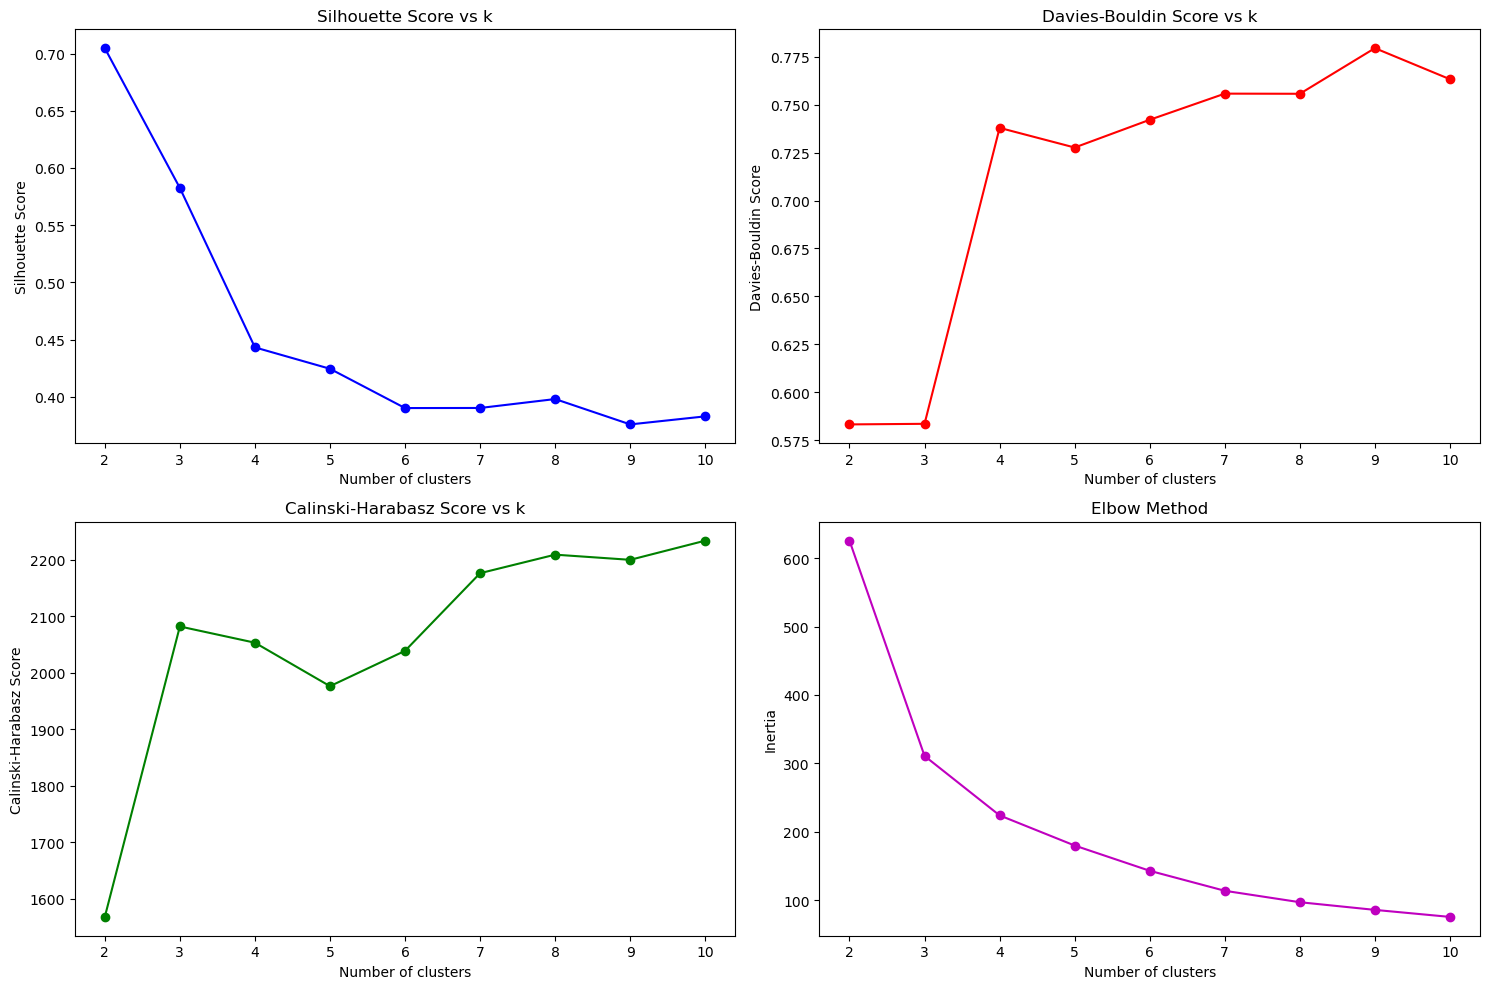

In [11]:
# Define function to evaluate cluster quality for different k values
def evaluate_clusters(X, max_k=10):
    """
    Evaluate optimal number of clusters using multiple metrics
    Returns a DataFrame with scores for each k
    """
    # Initialize empty list to store results
    results = []
    
    # Test cluster numbers from 2 to max_k
    for k in range(2, max_k+1):
        # Create KMeans instance with current k value
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)  # Added n_init=10
        # Fit model and predict clusters
        labels = kmeans.fit_predict(X)
        
        # Calculate evaluation metrics
        silhouette = silhouette_score(X, labels)  # Measures cluster separation
        davies_bouldin = davies_bouldin_score(X, labels)  # Measures cluster compactness
        calinski_harabasz = calinski_harabasz_score(X, labels)  # Measures variance ratio
        
        # Store results for current k
        results.append({
            'k': k,  # Number of clusters
            'silhouette': silhouette,  # Silhouette score
            'davies_bouldin': davies_bouldin,  # Davies-Bouldin score
            'calinski_harabasz': calinski_harabasz,  # Calinski-Harabasz score
            'inertia': kmeans.inertia_  # Sum of squared distances to centers
        })
    
    # Convert results to DataFrame
    return pd.DataFrame(results)

# Calculate metrics for different cluster numbers
cluster_metrics = evaluate_clusters(X)

# Create figure for visualization
plt.figure(figsize=(15, 10))

# Plot Silhouette Score (subplot 1)
plt.subplot(2, 2, 1)
plt.plot(cluster_metrics['k'], cluster_metrics['silhouette'], 'bo-')  # Blue line with markers
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')  # Higher values indicate better clustering

# Plot Davies-Bouldin Score (subplot 2)
plt.subplot(2, 2, 2)
plt.plot(cluster_metrics['k'], cluster_metrics['davies_bouldin'], 'ro-')  # Red line with markers
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score vs k')  # Lower values indicate better clustering

# Plot Calinski-Harabasz Score (subplot 3)
plt.subplot(2, 2, 3)
plt.plot(cluster_metrics['k'], cluster_metrics['calinski_harabasz'], 'go-')  # Green line with markers
plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score vs k')  # Higher values indicate better clustering

# Plot Inertia (subplot 4)
plt.subplot(2, 2, 4)
plt.plot(cluster_metrics['k'], cluster_metrics['inertia'], 'mo-')  # Magenta line with markers
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')  # Used to find optimal k at the "elbow" point

# Adjust layout and display plot
plt.tight_layout()
plt.show()


K-MEANS CLUSTERING (K=3)

K-Means Results (K=3):
Silhouette Score: 0.583 (higher = better)
Davies-Bouldin Score: 0.583 (lower = better)

Cluster Distribution:
KMeans_Cluster
0    745
2    212
1     43
Name: count, dtype: int64

Cluster Profiles (Numerical Features - Mean Values):
                 age  gender  income  spending_score  purchase_frequency  \
KMeans_Cluster                                                             
0               0.51    1.00   -0.08            0.50                0.52   
1               0.49    0.88    0.35            0.54                0.49   
2               0.50    0.89    0.20            0.50                0.53   

                preferred_category  last_purchase_amount  \
KMeans_Cluster                                             
0                             2.05                  0.44   
1                             2.14                 -1.59   
2                             1.92                 -1.21   

                income_spending_rati

c:\Users\Pranadh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


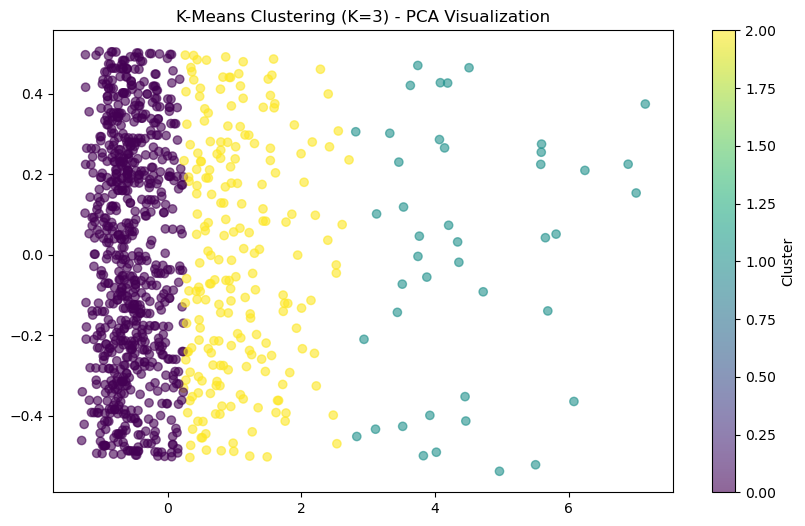

In [12]:
# ======================
# K-MEANS CLUSTERING (Optimal K=3)
# ======================
print("\n" + "="*40)
print("K-MEANS CLUSTERING (K=3)")
print("="*40)

# 1. Fit K-Means with optimal K=3
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Create a temporary DataFrame for analysis (preserve original)
analysis_df = df.copy()
analysis_df['KMeans_Cluster'] = kmeans_labels

# 2. Evaluate clusters
from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette_avg = silhouette_score(X, kmeans_labels)
db_score = davies_bouldin_score(X, kmeans_labels)

print(f"\nK-Means Results (K=3):")
print(f"Silhouette Score: {silhouette_avg:.3f} (higher = better)")
print(f"Davies-Bouldin Score: {db_score:.3f} (lower = better)")
print("\nCluster Distribution:")
print(analysis_df['KMeans_Cluster'].value_counts())

# 3. Cluster Profiling
# Separate numerical and categorical columns
numerical_cols = analysis_df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = analysis_df.select_dtypes(include=['object', 'category']).columns

# Remove cluster label from numerical features if it exists
numerical_cols = numerical_cols.drop('KMeans_Cluster', errors='ignore')

print("\nCluster Profiles (Numerical Features - Mean Values):")
print(analysis_df.groupby('KMeans_Cluster')[numerical_cols].mean().round(2))

if len(categorical_cols) > 0:
    print("\nCluster Profiles (Categorical Features - Distribution):")
    for col in categorical_cols:
        print(f"\n-- {col} --")
        print(analysis_df.groupby('KMeans_Cluster')[col].value_counts(normalize=True).round(2))

# 4. Visualization (PCA)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering (K=3) - PCA Visualization')
plt.colorbar(label='Cluster')
plt.show()

# Return the clustered DataFrame
df['KMeans_Cluster'] = kmeans_labels


HIERARCHICAL CLUSTERING


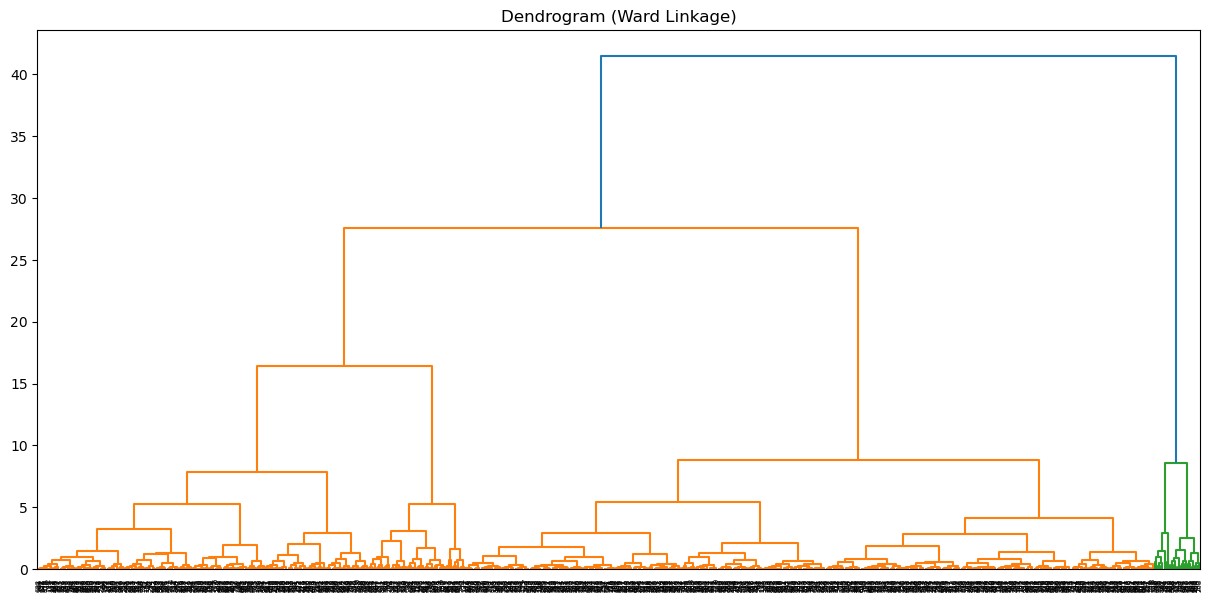


Hierarchical Clustering Results (K=3):
Silhouette Score: 0.482 (higher = better)
Cluster Distribution:
Hierarchical_Cluster
2    594
0    367
1     39
Name: count, dtype: int64


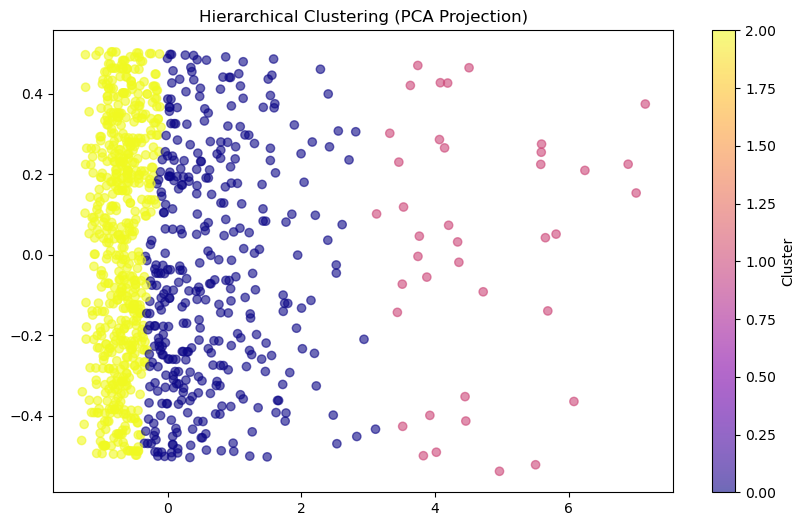

In [13]:
# =============================
# 2. Hierarchical Clustering
# =============================
print("\n" + "="*40)
print("HIERARCHICAL CLUSTERING")
print("="*40)

# Create dendrogram to visualize clustering structure
plt.figure(figsize=(15,7))
linked = linkage(X, method='ward')  # Ward's method minimizes variance
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram (Ward Linkage)')
plt.show()

# Perform hierarchical clustering with 3 clusters
hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X)

# Store cluster labels in dataframe
df['Hierarchical_Cluster'] = hierarchical_labels

# Evaluate clustering performance
silhouette_avg = silhouette_score(X, hierarchical_labels)
print(f"\nHierarchical Clustering Results (K=3):")
print(f"Silhouette Score: {silhouette_avg:.3f} (higher = better)")
print("Cluster Distribution:")
print(df['Hierarchical_Cluster'].value_counts())

# Visualize clusters using same PCA projection as before
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hierarchical_labels, cmap='plasma', alpha=0.6)
plt.title('Hierarchical Clustering (PCA Projection)')
plt.colorbar(label='Cluster')
plt.show()

In [14]:
# ======================
# Cluster Comparison
# ======================
print("\n" + "="*40)
print("CLUSTER COMPARISON")
print("="*40)

# Show first 10 rows of cluster assignments from both methods
comparison = df[['KMeans_Cluster', 'Hierarchical_Cluster']]
print("\nCluster Assignment Comparison:")
print(comparison.head(10))

# Analyze numerical features by K-Means clusters
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
cluster_profile_data = df[numerical_cols.tolist() + ['KMeans_Cluster']]  # Include cluster labels

print("\nCluster Profiles (K-Means - Numerical Features):")
print(cluster_profile_data.groupby('KMeans_Cluster').mean().round(2))  # Show mean values

# Analyze categorical features by K-Means clusters
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
if not categorical_cols.empty:
    cluster_cat_data = df[categorical_cols.tolist() + ['KMeans_Cluster']]  # Include cluster labels
    print("\nCluster Profiles (K-Means - Categorical Features):")
    # Show mode (most frequent value) for each category
    print(cluster_cat_data.groupby('KMeans_Cluster').agg(lambda x: x.mode()[0])) 


CLUSTER COMPARISON

Cluster Assignment Comparison:
   KMeans_Cluster  Hierarchical_Cluster
0               2                     0
1               2                     0
2               0                     0
3               0                     2
4               0                     0
5               2                     0
6               0                     0
7               0                     2
8               0                     2
9               0                     2

Cluster Profiles (K-Means - Numerical Features):
                 age  gender  income  spending_score  purchase_frequency  \
KMeans_Cluster                                                             
0               0.51    1.00   -0.08            0.50                0.52   
1               0.49    0.88    0.35            0.54                0.49   
2               0.50    0.89    0.20            0.50                0.53   

                preferred_category  last_purchase_amount  \
KMeans_Cluster   

In [15]:
# Prepare data for classification using K-Means clusters (K=3) as labels
X = df.drop(columns=['KMeans_Cluster', 'Hierarchical_Cluster'], errors='ignore')  # Features
y = df['KMeans_Cluster']  # Cluster labels from K-Means as target variable

# Split into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42  # For reproducibility
)

# Print dataset shapes and class distribution
print(f"Training set shape: {X_train.shape}")  # Show training data dimensions
print(f"Test set shape: {X_test.shape}")      # Show test data dimensions
print("\nClass distribution in training set:")
print(y_train.value_counts())  # Show count of samples per cluster
print(y_test.value_counts())  # Show count of samples per cluster

Training set shape: (700, 9)
Test set shape: (300, 9)

Class distribution in training set:
KMeans_Cluster
0    526
2    147
1     27
Name: count, dtype: int64
KMeans_Cluster
0    219
2     65
1     16
Name: count, dtype: int64



Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      0.94      0.97        16
           2       0.97      0.98      0.98        65

    accuracy                           0.99       300
   macro avg       0.99      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300


Confusion Matrix:


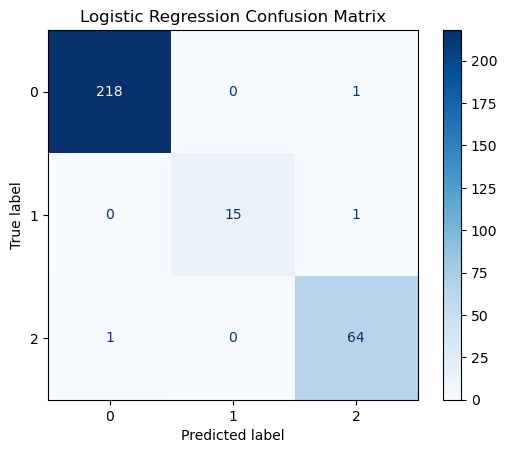


Accuracy: 0.9900


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

print("\n" + "="*50)
print("Logistic Regression")
print("="*50)

# Data Preparation ---------------------------------------------------
# Convert all features to numeric (safety check)
X_train_fixed = X_train.apply(pd.to_numeric, errors='coerce')
X_test_fixed = X_test.apply(pd.to_numeric, errors='coerce')

# Model Training -----------------------------------------------------
# Multinomial logistic regression with increased iterations
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_fixed, y_train)

# Model Evaluation ---------------------------------------------------
y_pred = lr.predict(X_test_fixed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))  # Precision/recall/F1 scores

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(lr, X_test_fixed, y_test, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  # Overall accuracy


Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       0.98      1.00      0.99        65
           2       1.00      0.94      0.97        16

    accuracy                           1.00       300
   macro avg       0.99      0.98      0.99       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:


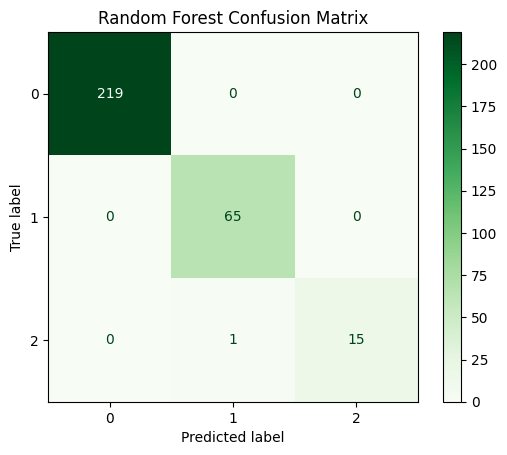


Accuracy: 0.9967


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Print section header
print("\n" + "="*50)
print("Random Forest")
print("="*50)

# Initialize Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)  
rf.fit(X_train, y_train)  # Train model on training data

# Make predictions on test set
y_pred = rf.predict(X_test)

# Model evaluation metrics
print("\nClassification Report:")  # Shows precision, recall, f1-score
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Greens')
plt.title('Random Forest Confusion Matrix')  #
plt.show()

# Print overall accuracy
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  


Support Vector Machine

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       219
           1       0.98      0.97      0.98        65
           2       1.00      0.94      0.97        16

    accuracy                           0.99       300
   macro avg       0.99      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300


Confusion Matrix:


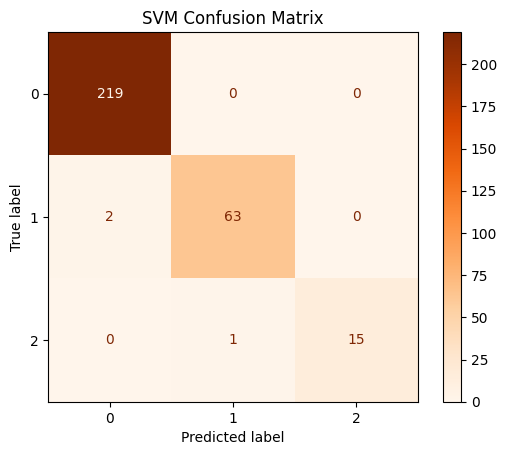


Accuracy: 0.9900


In [ ]:
from sklearn.svm import SVC

# Print section header
print("\n" + "="*50)
print("Support Vector Machine")
print("="*50)

# Initialize SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42) 
svm.fit(X_train, y_train)  # Train the model

# Generate predictions
y_pred = svm.predict(X_test)  

# Model evaluation
print("\nClassification Report:")  # Precision/recall/F1 scores
print(classification_report(y_test, y_pred))

# Visualize performance
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap='Oranges')
plt.title('SVM Confusion Matrix')  
plt.show()

# Print overall accuracy
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  


K-Nearest Neighbors

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       219
           1       0.92      0.86      0.89        65
           2       1.00      0.81      0.90        16

    accuracy                           0.95       300
   macro avg       0.96      0.89      0.92       300
weighted avg       0.95      0.95      0.95       300


Confusion Matrix:


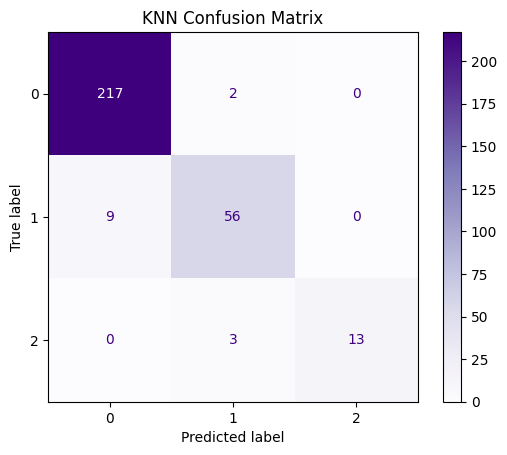


Accuracy: 0.9533


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Print section header
print("\n" + "="*50)
print("K-Nearest Neighbors")
print("="*50)

# Initialize KNN classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)  # Using 5 nearest points for classification
knn.fit(X_train, y_train)  # Train the model

# Make predictions on test data
y_pred = knn.predict(X_test)  

# Evaluate model performance
print("\nClassification Report:")  
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap='Purples')
plt.title('KNN Confusion Matrix')  # Visual representation of predictions
plt.show()

# Print overall accuracy score
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  


Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00        16

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:


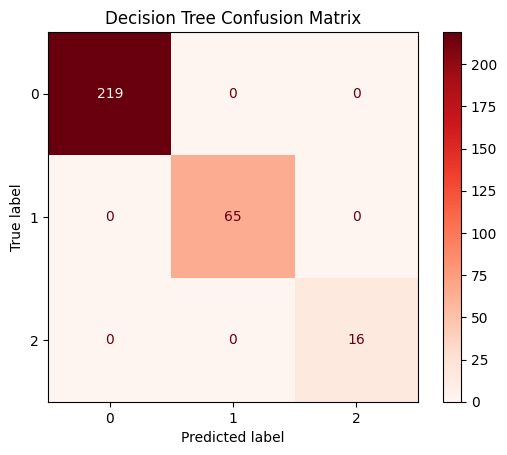


Accuracy: 1.0000


In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("\n" + "="*50)
print("Decision Tree")
print("="*50)

# Initialize and train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap='Reds')
plt.title('Decision Tree Confusion Matrix')
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")


XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       219
           1       0.97      0.98      0.98        65
           2       1.00      0.94      0.97        16

    accuracy                           0.99       300
   macro avg       0.99      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300


Confusion Matrix:


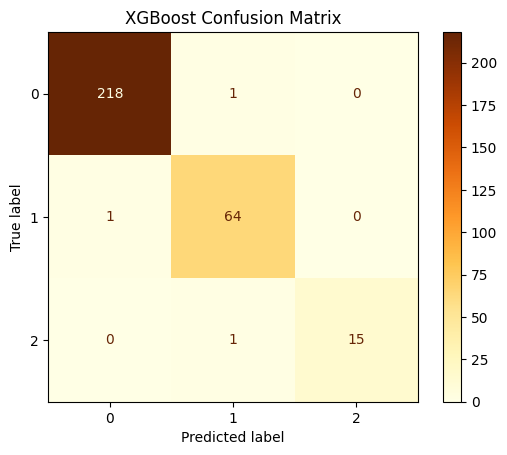


Accuracy: 0.9900


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

print("\n" + "="*50)
print("XGBoost")
print("="*50)

#  Convert categorical columns to numeric codes 
if 'loyalty_tier' in X_train.columns:
    X_train_fixed = X_train.copy()
    X_test_fixed = X_test.copy()
    X_train_fixed['loyalty_tier'] = X_train_fixed['loyalty_tier'].cat.codes
    X_test_fixed['loyalty_tier'] = X_test_fixed['loyalty_tier'].cat.codes
else:
    X_train_fixed = X_train.copy()
    X_test_fixed = X_test.copy()


# Initialize and train
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb.fit(X_train_fixed, y_train)

# Predictions
y_pred = xgb.predict(X_test_fixed)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(xgb, X_test_fixed, y_test, cmap='YlOrBr')
plt.title('XGBoost Confusion Matrix')
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")


MODEL PERFORMANCE COMPARISON

Model Performance Comparison:
                     accuracy  precision    recall        f1
Decision Tree        1.000000   1.000000  1.000000  1.000000
Random Forest        0.996667   0.996717  0.996667  0.996626
Logistic Regression  0.990000   0.990101  0.990000  0.989984
SVM                  0.990000   0.990008  0.990000  0.989923
XGBoost              0.990000   0.990101  0.990000  0.989984
KNN                  0.953333   0.953170  0.953333  0.952364


<Figure size 1200x600 with 0 Axes>

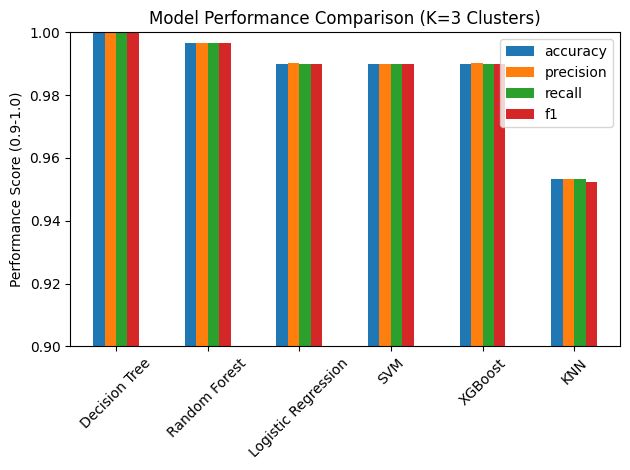

In [ ]:
# Import required libraries
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Print section header for clarity
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)

def get_model_metrics(model, X, y_true, model_name):
    """Calculate and return key performance metrics for a model"""
    y_pred = model.predict(X)  # Generate predictions
    report = classification_report(y_true, y_pred, output_dict=True)  # Get detailed metrics
    
    # Extract and return weighted average metrics
    return {
        'accuracy': accuracy_score(y_true, y_pred),  # Overall prediction accuracy
        'precision': report['weighted avg']['precision'],  # Positive predictive value
        'recall': report['weighted avg']['recall'],  # True positive rate
        'f1': report['weighted avg']['f1-score']  # Balance between precision and recall
    }

# Prepare test data for evaluation
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)  # Ensure numeric values

# Dictionary of models to compare with their appropriate input data
models = {
    'Logistic Regression': (lr, X_test_numeric),  # Requires scaled data
    'Random Forest': (rf, X_test_numeric),
    'SVM': (svm, X_test_numeric),
    'KNN': (knn, X_test_numeric),
    'Decision Tree': (dt, X_test_numeric),
    'XGBoost': (xgb, X_test_numeric)
}

# Calculate metrics for each model
results = {}
for name, (model, data) in models.items():
    results[name] = get_model_metrics(model, data, y_test, name)

# Create and sort results dataframe by accuracy
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values('accuracy', ascending=False)

# Display numerical results
print("\nModel Performance Comparison:")
print(results_df)

# Visualize results with enhanced y-axis focus
plt.figure(figsize=(12,6))
results_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
plt.title('Model Performance Comparison (K=3 Clusters)')
plt.ylabel('Performance Score (0.9-1.0)')
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)  # Focused range to highlight differences
plt.tight_layout()
plt.show()